In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformer import ThermalTransformer
from loader import load_data

In [19]:
#holdout = None
holdout = [-12.502,-29.500,-41.900]

# Load base dataset
train_loader,train_val_loader,test_loader = load_data('../data/full_dataset/data_rearranged.csv',holdout=holdout,batch_size=16)
# load once-augmented dataset
#train_loader,train_val_loader,test_loader = load_data('../data/full_dataset/full_with_snr15.62.csv',holdout=holdout,batch_size=16)
# load twice-augmented dataset
# train_loader,train_val_loader,test_loader = load_data('../data/full_dataset/full_with_snr15.62_snr5.22.csv',holdout=holdout,batch_size=16)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.MSELoss()

Held out: [-12.502, -29.5, -41.9]


In [20]:
base_lr = 4e-4
thermal_lr = 1e-2
hidden_dim = 15
model = ThermalTransformer(input_dim=5,d_model=hidden_dim,nhead=5).to(device).float()

thermal_params = [p for n, p in model.named_parameters() if 'log_beta' in n or 'mu' in n]
base_params = [p for n, p in model.named_parameters() if 'log_beta' not in n and 'mu' not in n]

optimizer = torch.optim.Adam([
    {'params': base_params, 'lr': base_lr}, 
    {'params': thermal_params, 'lr': thermal_lr}
])

num_epochs = 100
val_pts = []
train_pts = []

print(f"Training on {device}...")

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device).float(), batch_y.to(device).float()
        
        preds = model(batch_x)
        mse_loss = criterion(preds, batch_y)
        rmse_loss = torch.sqrt(mse_loss + 1e-15)
        
        optimizer.zero_grad()
        rmse_loss.backward()
        optimizer.step()
        
        total_train_loss += rmse_loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for batch_x, batch_y in train_val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            preds = model(batch_x)
            mse_loss = criterion(preds, batch_y)
            rmse_loss = torch.sqrt(mse_loss + 1e-15)
            total_val_loss += rmse_loss.item()

    avg_val_loss = total_val_loss / len(train_val_loader)
    
    # --- LOGGING ---
    if (epoch + 1) % 5 == 0 or epoch == 0:
        sample_beta = np.exp([x.log_beta.item() for x in model.heads])
        sample_mu = np.exp([x.mu.item() for x in model.heads])
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train RMSE: {avg_train_loss:.4f} | Test RMSE: {avg_val_loss:.4f} | Beta: {sample_beta} | Mu: {sample_mu}")
        print("-" * 30)
        val_pts.append(avg_val_loss)
        train_pts.append(avg_train_loss)

model.eval()
total_test_loss = 0

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        preds = model(batch_x)
        mse_loss = criterion(preds, batch_y)
        rmse_loss = torch.sqrt(mse_loss + 1e-15)
        total_test_loss += rmse_loss.item()
        
avg_test_loss = total_test_loss / len(test_loader)
print(f"Final Holdout Validation RMSE: {avg_test_loss}")


Training on cuda...
Epoch [1/100]
  Train RMSE: 3.4319 | Test RMSE: 2.3594 | Beta: [3.30288635e-02 8.32892753e-02 8.38422817e+01 3.20061578e+01
 2.29151371e+00] | Mu: [1.02148735 0.59759299 0.27348636 0.96023955 5.63986801]
------------------------------
Epoch [5/100]
  Train RMSE: 1.4728 | Test RMSE: 1.4491 | Beta: [8.00731158e-03 4.31136386e-02 8.37663158e+01 7.02852559e+01
 2.19008426e+00] | Mu: [0.89178406 0.83125345 0.27400075 1.08464664 0.74154693]
------------------------------
Epoch [10/100]
  Train RMSE: 1.0625 | Test RMSE: 1.2730 | Beta: [3.97134377e-03 5.38023109e-02 7.75104217e+02 7.02852559e+01
 8.30591504e+00] | Mu: [8.12570817e-01 6.62464416e-01 1.29980297e-02 1.08464664e+00
 5.55561414e+01]
------------------------------
Epoch [15/100]
  Train RMSE: 0.8512 | Test RMSE: 0.8791 | Beta: [1.93925028e-03 5.33865963e-02 7.85459069e+02 7.02852559e+01
 8.30591504e+00] | Mu: [7.72892347e-01 6.91887809e-01 1.27668506e-02 1.08464664e+00
 5.55561414e+01]
---------------------------

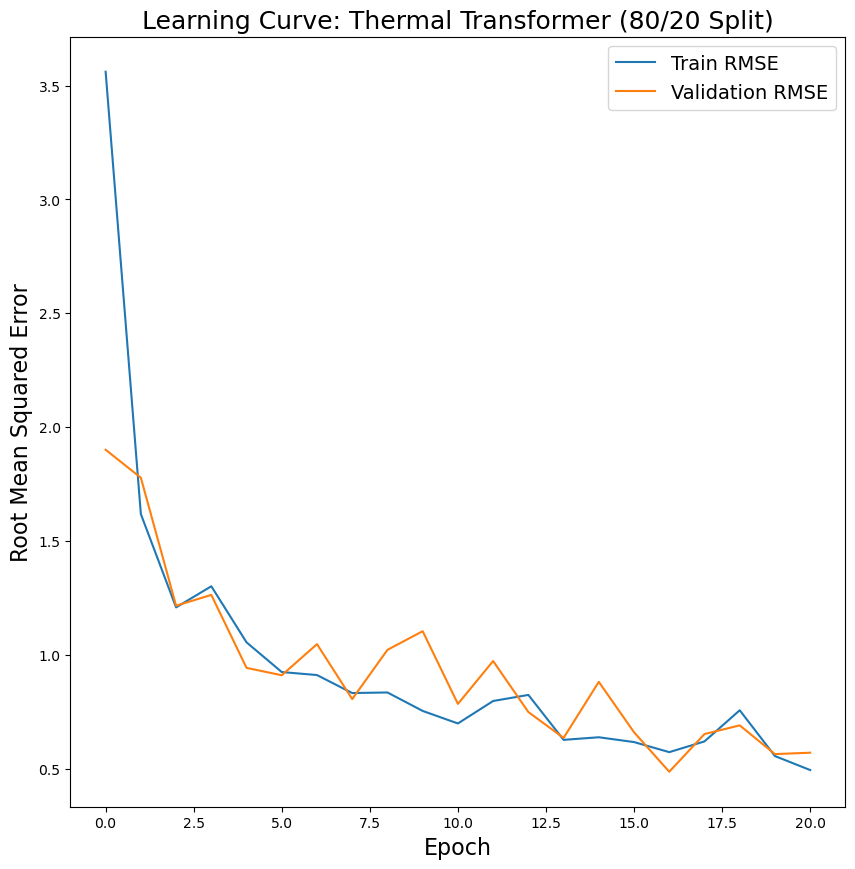

In [17]:
fig = plt.figure(figsize=(10,10))
plt.plot(train_pts,label="Train RMSE")
plt.plot(val_pts,label="Validation RMSE")
plt.title("Learning Curve: Thermal Transformer (80/20 Split)",size=18)
plt.xlabel("Epoch",size=16)
plt.ylabel("Root Mean Squared Error",size=16)
plt.legend(fontsize=14)

In [18]:
#fig.savefig("TV_curve_holdout.png")
fig.savefig("TV_curve.png")

In [107]:
# Specify a path
from datetime import datetime

now = datetime.now()
formatted_time = now.strftime("%d%B%Y-%H%M")
out_path = f"thermal_transformer_hidden-{hidden_dim}_base-{base_lr}_thermal-{thermal_lr}_{formatted_time}.pth"

torch.save(model.state_dict(), out_path)
print(f"Model parameters saved to {out_path}")

Model parameters saved to thermal_transformer_hidden-300_base-0.0008_thermal-0.08_02May2026-2016.pth


In [11]:
model = ThermalTransformer(input_dim=5, d_model=300, nhead=5).to(device).float()
model.load_state_dict(torch.load("thermal_transformer_hidden-300_base-0.0008_thermal-0.08_02_split.pth"))
model.eval()

total_test_loss = 0

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        preds = model(batch_x)
        mse_loss = criterion(preds, batch_y)
        rmse_loss = torch.sqrt(mse_loss + 1e-15)
        total_test_loss += rmse_loss.item()
        
avg_test_loss = total_test_loss / len(test_loader)
print(f"Final RMSE: {avg_test_loss}")

Final RMSE: 0.4620500909393697
